# Modelo XGBoost

## Ingeniería de variables

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, json, multiprocessing, joblib
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
from xgboost import XGBClassifier

from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

# ── Semilla global ─────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Configuración CPU / GPU (CUDA) ──────────────────────────────────────────
N_CPUS = max(1, multiprocessing.cpu_count() - 1)   # todos los núcleos menos 1

def detectar_dispositivo() -> str:
    """Intenta un fit mínimo en GPU; si falla, cae a CPU."""
    try:
        Xt = np.random.rand(16, 3); yt = np.array([0, 1] * 8)
        XGBClassifier(tree_method="hist", device="cuda",
                      n_estimators=2, verbosity=0).fit(Xt, yt)
        return "cuda"
    except Exception:
        return "cpu"

DEVICE = detectar_dispositivo()
if DEVICE == "cuda":
    print(f"   🟢 GPU detectada — XGBoost usando CUDA (tree_method='hist')")
else:
    print(f"   🟡 Sin GPU — XGBoost usando {N_CPUS} núcleos CPU")

# Patience (rondas de early stopping) — análogo al patience de las redes
ES_BASE_TUNED = 50
ES_FINAL      = 75

DIRS = {
    "modelos":  "modelo_final",
    "graficos": "plots/modelos_xgboost",     # NUEVA carpeta para gráficos
    "ablation": "ablation_study_xgboost",    # NUEVA carpeta para ablation
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

   🟢 GPU detectada — XGBoost usando CUDA (tree_method='hist')


## 1. Carga y limpieza de datos crudos (UCI id=2)

In [18]:
print("─" * 65)
print("1. Cargando datos crudos desde UCI (Adult / Census Income)...")

adult = fetch_ucirepo(id=2)
df_raw = adult.data.original

df_raw.replace('?', np.nan, inplace=True)
df_raw['income'] = df_raw['income'].str.strip().replace({'<=50K.': '<=50K', '>50K.': '>50K'})
df_raw['native-country'] = df_raw['native-country'].replace({
    'South': 'South-Korea',
    'Hong': 'Hong-Kong'
})

df_raw.drop(columns=['fnlwgt'], inplace=True)
print(f"   df_raw: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")

─────────────────────────────────────────────────────────────────
1. Cargando datos crudos desde UCI (Adult / Census Income)...
   df_raw: 48842 filas × 14 columnas


## 2. Ingeniería de variables (pipeline *lean*)

In [19]:
REGIONALIZAR = True   # agrupar native-country en regiones (recomendado)

def regionalizar_paises(X):
    X_copy = X.copy()
    region_mapping = {
        # Norteamérica
        'United-States': 'EEUU',
        'Canada': 'Norteamerica_Otros',
        'Outlying-US(Guam-USVI-etc)': 'Norteamerica_Otros',
        # Latinoamérica y Caribe
        'Mexico': 'Latinoamerica', 'Puerto-Rico': 'Latinoamerica', 'El-Salvador': 'Latinoamerica',
        'Cuba': 'Latinoamerica', 'Jamaica': 'Latinoamerica', 'Dominican-Republic': 'Latinoamerica',
        'Guatemala': 'Latinoamerica', 'Columbia': 'Latinoamerica', 'Haiti': 'Latinoamerica',
        'Nicaragua': 'Latinoamerica', 'Peru': 'Latinoamerica', 'Ecuador': 'Latinoamerica',
        'Trinadad&Tobago': 'Latinoamerica', 'Honduras': 'Latinoamerica',
        'Argentina': 'Latinoamerica', 'Chile': 'Latinoamerica', 'Brasil': 'Latinoamerica', 'Venezuela': 'Latinoamerica',
        # Europa
        'Germany': 'Europa', 'England': 'Europa', 'Italy': 'Europa', 'Poland': 'Europa',
        'Portugal': 'Europa', 'Greece': 'Europa', 'France': 'Europa', 'Ireland': 'Europa',
        'Yugoslavia': 'Europa', 'Scotland': 'Europa', 'Hungary': 'Europa', 'Holand-Netherlands': 'Europa',
        # Asia  (incluye la variante con guion 'Hong-Kong' que produce la limpieza)
        'Philippines': 'Asia', 'India': 'Asia', 'China': 'Asia', 'Japan': 'Asia',
        'Vietnam': 'Asia', 'Taiwan': 'Asia', 'Iran': 'Asia', 'Hong Kong': 'Asia', 'Hong-Kong': 'Asia',
        'Thailand': 'Asia', 'Cambodia': 'Asia', 'Laos': 'Asia', 'South-Korea': 'Asia',
    }
    X_copy['region'] = X_copy['native-country'].map(region_mapping)
    X_copy = X_copy.drop('native-country', axis=1)
    return X_copy


# Columnas finales del pipeline lean
NUM_COLS = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num']
CAT_BASE = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']


def preparar_base(df: pd.DataFrame):
    """Aplica las decisiones de feature engineering y devuelve (X_features, cat_cols)."""
    X = df.copy()
    if REGIONALIZAR:
        X = regionalizar_paises(X)          # añade 'region', elimina 'native-country'
        pais = 'region'
    else:
        pais = 'native-country'
    # Conservar education-num (ordinal); descartar el string 'education'
    if 'education' in X.columns:
        X = X.drop(columns=['education'])
    cat_cols = CAT_BASE + [pais]
    # Tipos: numéricas a número, categóricas a object
    for c in NUM_COLS:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    for c in cat_cols:
        X[c] = X[c].astype('object')
    return X[NUM_COLS + cat_cols], cat_cols


class CastCategorias:
    """Fija las categorías aprendidas en train para las columnas categóricas
    (dtype 'category'); en test, categorías no vistas → NaN (XGBoost las maneja)."""
    def __init__(self, cat_cols): self.cat_cols = cat_cols
    def fit(self, X, y=None):
        self.categorias_ = {c: pd.unique(X[c].dropna()) for c in self.cat_cols}
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.cat_cols:
            X[c] = pd.Categorical(X[c], categories=self.categorias_[c])
        return X


def build_ohe(cat_cols):
    """ColumnTransformer one-hot: numéricas passthrough (sin escalar),
    categóricas imputadas a 'Desconocido' + OneHotEncoder."""
    return ColumnTransformer([
        ('num', 'passthrough', NUM_COLS),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value='Desconocido')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols),
    ], remainder='drop')

### Split crudo (80/20 estratificado) y codificación (nativo + one-hot)

In [20]:
print("\n2. Aplicando ingeniería de variables (lean: nativo vs one-hot)...")

X_feat, CAT_COLS = preparar_base(df_raw.drop(columns=['income']))
y_all = df_raw['income'].map({'<=50K': 0, '>50K': 1})

# Split crudo (antes de codificar) — estratificado
X_train_raw, X_test_raw, y_train_s, y_test_s = train_test_split(
    X_feat, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

# — Encoding NATIVO (categóricas dtype 'category', NaN nativo) —
cast = CastCategorias(CAT_COLS).fit(X_train_raw)
Xnat_train_full = cast.transform(X_train_raw)
Xnat_test       = cast.transform(X_test_raw)

# — Encoding ONE-HOT (sin escalar; 'Desconocido' explícito) —
ohe_ct = build_ohe(CAT_COLS)
Xohe_train_full = ohe_ct.fit_transform(X_train_raw)
Xohe_test       = ohe_ct.transform(X_test_raw)

y_train_full = y_train_s.values
y_test       = y_test_s.values

print(f"   nativo  — X_train: {Xnat_train_full.shape}  ({len(NUM_COLS)} num + {len(CAT_COLS)} cat)")
print(f"   one-hot — X_train: {Xohe_train_full.shape}")
print(f"   Balance train: {y_train_full.mean():.1%} positivos")


2. Aplicando ingeniería de variables (lean: nativo vs one-hot)...
   nativo  — X_train: (39073, 12)  (5 num + 7 cat)
   one-hot — X_train: (39073, 55)
   Balance train: 23.9% positivos


## 3. Preparación para XGBoost (split de validación y `scale_pos_weight`)

In [21]:
# Pipeline PRINCIPAL: 'nat' (categóricas nativas, recomendado) | 'ohe' (one-hot)
PRINCIPAL = "nat"

INPUT_DIM_NAT = Xnat_train_full.shape[1]
INPUT_DIM_OHE = Xohe_train_full.shape[1]

# ── Split train → train (85%) + validación (15%) ───────────────────────────
Xnat_train, Xnat_val, y_train, y_val = train_test_split(
    Xnat_train_full, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)
Xohe_train, Xohe_val, _, _ = train_test_split(
    Xohe_train_full, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)
print(f"   Train: {Xnat_train.shape[0]} | Val: {Xnat_val.shape[0]} | Test: {Xnat_test.shape[0]}")

# Asignación principal / secundario
if PRINCIPAL == "nat":
    Xtr_P, Xva_P, Xfull_P, Xte_P, CAT_P = Xnat_train, Xnat_val, Xnat_train_full, Xnat_test, True
    Xtr_S, Xva_S, Xfull_S, Xte_S, CAT_S = Xohe_train, Xohe_val, Xohe_train_full, Xohe_test, False
    SECUNDARIO = "ohe"
else:
    Xtr_P, Xva_P, Xfull_P, Xte_P, CAT_P = Xohe_train, Xohe_val, Xohe_train_full, Xohe_test, False
    Xtr_S, Xva_S, Xfull_S, Xte_S, CAT_S = Xnat_train, Xnat_val, Xnat_train_full, Xnat_test, True
    SECUNDARIO = "nat"
print(f"   Pipeline principal: '{PRINCIPAL}' | secundario: '{SECUNDARIO}'")

# ── Pesos de clase → scale_pos_weight ───────────────────────────────────────
clases = np.array([0, 1])
pesos  = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))
SCALE_POS_WEIGHT  = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"   class_weight: {class_weight_dict}")
print(f"   scale_pos_weight (neg/pos): {SCALE_POS_WEIGHT:.4f}")

   Train: 33212 | Val: 5861 | Test: 9769
   Pipeline principal: 'nat' | secundario: 'ohe'
   class_weight: {np.int64(0): np.float64(0.6572729071838512), np.int64(1): np.float64(2.089593557317227)}
   scale_pos_weight (neg/pos): 3.1792


## 4. Helpers

In [22]:
def build_base_model(cat: bool) -> XGBClassifier:
    """XGBoost base con hiperparámetros por defecto razonables + CUDA.
    cat=True activa el soporte nativo de categóricas (enable_categorical)."""
    return XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective="binary:logistic", eval_metric=["logloss", "auc"],
        early_stopping_rounds=ES_BASE_TUNED,
        scale_pos_weight=SCALE_POS_WEIGHT,
        tree_method="hist", device=DEVICE, enable_categorical=cat,
        n_jobs=N_CPUS, random_state=SEED, verbosity=0,
    )


def build_tuned_model(params: dict, cat: bool,
                      early_stopping_rounds: int = ES_BASE_TUNED) -> XGBClassifier:
    """XGBoost parametrizable (hiperparámetros de Optuna) + CUDA."""
    return XGBClassifier(
        objective="binary:logistic", eval_metric=["logloss", "auc"],
        early_stopping_rounds=early_stopping_rounds,
        scale_pos_weight=SCALE_POS_WEIGHT,
        tree_method="hist", device=DEVICE, enable_categorical=cat,
        n_jobs=N_CPUS, random_state=SEED, verbosity=0,
        **params,
    )


def fit_model(model: XGBClassifier, X_tr, y_tr, X_va, y_va, verbose=False) -> dict:
    """Entrena con eval_set monitorizando AUC (early stopping) y devuelve un
    history dict con claves: loss, val_loss, auc, val_auc (análogo a las redes)."""
    model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=verbose)
    ev = model.evals_result()
    return {
        'loss':     ev['validation_0']['logloss'],
        'val_loss': ev['validation_1']['logloss'],
        'auc':      ev['validation_0']['auc'],
        'val_auc':  ev['validation_1']['auc'],
    }


def evaluar_modelo(model, X, y, nombre="Modelo") -> dict:
    prob  = model.predict_proba(X)[:, 1]
    pred  = (prob >= 0.5).astype(int)
    auc   = roc_auc_score(y, prob)
    f1    = f1_score(y, pred)
    acc   = accuracy_score(y, pred)
    pr_auc = average_precision_score(y, prob)
    cm    = confusion_matrix(y, pred)
    print(f"\n  {nombre}")
    print(f"    ROC-AUC : {auc:.4f} | PR-AUC : {pr_auc:.4f} | F1 : {f1:.4f} | Acc : {acc:.4f}")
    return {'nombre': nombre, 'auc': auc, 'pr_auc': pr_auc,
            'f1': f1, 'acc': acc, 'prob': prob, 'pred': pred, 'cm': cm}


def guardar_experimento(model, historia_dict: dict,
                        res_nat: dict, res_ohe: dict,
                        experimento: str, params: dict = None) -> dict:
    """Guarda modelo .json, métricas .json, historia .json y gráficos .png."""
    slug    = experimento.lower().replace(" ", "_").replace("/", "-")
    exp_dir = os.path.join(DIRS["ablation"], slug)
    os.makedirs(exp_dir, exist_ok=True)

    # — Modelo ——————————————————————————————————————————————————————————————
    model.save_model(os.path.join(exp_dir, "modelo.json"))

    # — Métricas ————————————————————————————————————————————————————————————
    def limpiar(d):
        return {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                for k, v in d.items() if k not in ['prob', 'pred', 'cm']}

    metricas = {
        "experimento":       experimento,
        "params":            params or {},
        "pipeline_nat":      limpiar(res_nat),
        "pipeline_ohe":      limpiar(res_ohe),
        "epocas_entrenadas": len(historia_dict['loss']),
    }
    with open(os.path.join(exp_dir, "metricas.json"), "w") as f:
        json.dump(metricas, f, indent=2)

    # — Historia ————————————————————————————————————————————————————————————
    with open(os.path.join(exp_dir, "historia_entrenamiento.json"), "w") as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in historia_dict.items()}, f, indent=2)

    # — Gráficos ————————————————————————————————————————————————————————————
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle(f"Ablation — {experimento}", fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax = fig.add_subplot(gs[0, 0])
    ax.plot(historia_dict['loss'],     label='Train')
    ax.plot(historia_dict['val_loss'], label='Val', linestyle='--')
    ax.set_title("Learning Curve — LogLoss")
    ax.set_xlabel("Ronda (árbol)"); ax.set_ylabel("LogLoss"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    ax.plot(historia_dict['auc'],     label='Train')
    ax.plot(historia_dict['val_auc'], label='Val', linestyle='--')
    ax.set_title("Learning Curve — AUC")
    ax.set_xlabel("Ronda (árbol)"); ax.set_ylabel("AUC"); ax.legend()

    ax = fig.add_subplot(gs[0, 2])
    for res, lbl in [(res_nat, 'nativo'), (res_ohe, 'one-hot')]:
        fpr, tpr, _ = roc_curve(y_test, res['prob'])
        ax.plot(fpr, tpr, label=f"{lbl} ({res['auc']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title("Curva ROC"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 0])
    for res, lbl in [(res_nat, 'nativo'), (res_ohe, 'one-hot')]:
        prec, rec, _ = precision_recall_curve(y_test, res['prob'])
        ax.plot(rec, prec, label=f"{lbl} ({res['pr_auc']:.3f})")
    ax.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
               label=f'Baseline ({y_test.mean():.2f})')
    ax.set_title("Curva PR"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    ConfusionMatrixDisplay(res_nat['cm'],
                           display_labels=['<=50K', '>50K']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"CM — nativo (F1={res_nat['f1']:.3f})")

    ax = fig.add_subplot(gs[1, 2])
    ConfusionMatrixDisplay(res_ohe['cm'],
                           display_labels=['<=50K', '>50K']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"CM — one-hot (F1={res_ohe['f1']:.3f})")

    plt.savefig(os.path.join(exp_dir, "graficos.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"   ✅ Experimento '{experimento}' guardado en {exp_dir}/")
    return metricas

## 5. Modelo base

In [23]:
print("\n" + "─" * 65)
print("3. Entrenando MODELO BASE...")

modelo_base = build_base_model(CAT_P)
hist_base = fit_model(modelo_base, Xtr_P, y_train, Xva_P, y_val)
print(f"   Mejor iteración (early stopping): {modelo_base.best_iteration}")

modelo_base_sec = build_base_model(CAT_S)
fit_model(modelo_base_sec, Xtr_S, y_train, Xva_S, y_val)

# Mapear a etiquetas nat/ohe para evaluación y guardado
modelo_base_nat = modelo_base if PRINCIPAL == "nat" else modelo_base_sec
modelo_base_ohe = modelo_base if PRINCIPAL == "ohe" else modelo_base_sec

res_base_nat = evaluar_modelo(modelo_base_nat, Xnat_test, y_test, "Base / nativo")
res_base_ohe = evaluar_modelo(modelo_base_ohe, Xohe_test, y_test, "Base / one-hot")

metricas_base = guardar_experimento(
    model=modelo_base,
    historia_dict=hist_base,
    res_nat=res_base_nat,
    res_ohe=res_base_ohe,
    experimento="01_modelo_base",
    params={"n_estimators": 600, "max_depth": 6, "learning_rate": 0.1,
            "pipeline_principal": PRINCIPAL, "regionalizar": REGIONALIZAR},
)


─────────────────────────────────────────────────────────────────
3. Entrenando MODELO BASE...
   Mejor iteración (early stopping): 133

  Base / nativo
    ROC-AUC : 0.9315 | PR-AUC : 0.8361 | F1 : 0.7116 | Acc : 0.8336

  Base / one-hot
    ROC-AUC : 0.9314 | PR-AUC : 0.8354 | F1 : 0.7151 | Acc : 0.8353
   ✅ Experimento '01_modelo_base' guardado en ablation_study_xgboost\01_modelo_base/


## 6. Búsqueda de hiperparámetros con Optuna

In [24]:
print("\n" + "─" * 65)
print("4. Búsqueda de hiperparámetros con Optuna (TPE, 30 trials)...")

def objective(trial: optuna.Trial) -> float:
    """Optimiza val_AUC sobre el pipeline principal."""
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1200, step=100),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    }
    m = build_tuned_model(params, cat=CAT_P)
    h = fit_model(m, Xtr_P, y_train, Xva_P, y_val)
    return max(h['val_auc'])

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="xgboost_adult_income"
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n   ✅ Mejor trial  : #{study.best_trial.number}")
print(f"   ✅ Mejor val_AUC: {study.best_value:.4f}")
print(f"   ✅ Mejores params: {study.best_params}")

trials_df = study.trials_dataframe()
trials_df.to_csv(os.path.join(DIRS["ablation"], "optuna_trials.csv"), index=False)

try:
    fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)
    fig_imp.figure.savefig(
        os.path.join(DIRS["ablation"], "optuna_param_importances.png"),
        dpi=150, bbox_inches='tight'
    )
    plt.close(fig_imp.figure)
except Exception:
    pass  # Requiere plotly; omitir si no está instalado


─────────────────────────────────────────────────────────────────
4. Búsqueda de hiperparámetros con Optuna (TPE, 30 trials)...


Best trial: 27. Best value: 0.930429: 100%|██████████| 30/30 [00:46<00:00,  1.55s/it]
C:\Users\PC\AppData\Local\Temp\ipykernel_31172\449960975.py:36: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)



   ✅ Mejor trial  : #27
   ✅ Mejor val_AUC: 0.9304
   ✅ Mejores params: {'n_estimators': 1100, 'max_depth': 7, 'learning_rate': 0.02685885189360138, 'subsample': 0.9630995159864814, 'colsample_bytree': 0.6303152210546972, 'min_child_weight': 1, 'gamma': 4.8211400345489965e-08, 'reg_lambda': 0.02418879832844087, 'reg_alpha': 3.089981531660265e-08}


### Re-entrenar modelo tuneado con los mejores hiperparámetros

In [25]:
# ── Mejores params ──────────────────────────────────────────────────────────
mejor_params = dict(study.best_params)

# ── Re-entrenar modelo tuneado con los mejores params ───────────────────────
modelo_tuneado = build_tuned_model(mejor_params, cat=CAT_P)
hist_tuneado = fit_model(modelo_tuneado, Xtr_P, y_train, Xva_P, y_val)

modelo_tuneado_sec = build_tuned_model(mejor_params, cat=CAT_S)
fit_model(modelo_tuneado_sec, Xtr_S, y_train, Xva_S, y_val)

modelo_tuneado_nat = modelo_tuneado if PRINCIPAL == "nat" else modelo_tuneado_sec
modelo_tuneado_ohe = modelo_tuneado if PRINCIPAL == "ohe" else modelo_tuneado_sec

res_tuneado_nat = evaluar_modelo(modelo_tuneado_nat, Xnat_test, y_test, "Tuneado / nativo")
res_tuneado_ohe = evaluar_modelo(modelo_tuneado_ohe, Xohe_test, y_test, "Tuneado / one-hot")

metricas_tuneado = guardar_experimento(
    model=modelo_tuneado,
    historia_dict=hist_tuneado,
    res_nat=res_tuneado_nat,
    res_ohe=res_tuneado_ohe,
    experimento="02_modelo_tuneado_optuna",
    params={**mejor_params, "optuna_trial": study.best_trial.number,
            "optuna_val_auc": study.best_value},
)


  Tuneado / nativo
    ROC-AUC : 0.9322 | PR-AUC : 0.8377 | F1 : 0.7157 | Acc : 0.8368

  Tuneado / one-hot
    ROC-AUC : 0.9317 | PR-AUC : 0.8364 | F1 : 0.7130 | Acc : 0.8343
   ✅ Experimento '02_modelo_tuneado_optuna' guardado en ablation_study_xgboost\02_modelo_tuneado_optuna/


## 7. Modelo final (reentrenado sobre train completo)

In [26]:
print("\n" + "─" * 65)
print("5. Entrenando MODELO FINAL sobre train completo...")

modelo_final = build_tuned_model(mejor_params, cat=CAT_P, early_stopping_rounds=ES_FINAL)
hist_final = fit_model(
    modelo_final, Xfull_P, y_train_full, Xte_P, y_test,  # test solo monitoreo
    verbose=False
)
print(f"   Mejor iteración (early stopping): {modelo_final.best_iteration}")

modelo_final_sec = build_tuned_model(mejor_params, cat=CAT_S, early_stopping_rounds=ES_FINAL)
hist_final_sec = fit_model(modelo_final_sec, Xfull_S, y_train_full, Xte_S, y_test)

modelo_final_nat = modelo_final if PRINCIPAL == "nat" else modelo_final_sec
modelo_final_ohe = modelo_final if PRINCIPAL == "ohe" else modelo_final_sec
hist_final_nat   = hist_final if PRINCIPAL == "nat" else hist_final_sec
hist_final_ohe   = hist_final if PRINCIPAL == "ohe" else hist_final_sec

modelo_final.save_model(os.path.join(DIRS["modelos"], "modelo_xgboost_final.json"))
modelo_final.save_model(os.path.join(DIRS["modelos"], "modelo_xgboost_best.json"))


joblib.dump(
    {"cast": cast, "ohe_ct": ohe_ct, "num_cols": NUM_COLS,
     "cat_cols": CAT_COLS, "regionalizar": REGIONALIZAR},
    os.path.join(DIRS["modelos"], "preprocesador_xgboost.pkl")
)

res_final_nat = evaluar_modelo(modelo_final_nat, Xnat_test, y_test, "Final / nativo")
res_final_ohe = evaluar_modelo(modelo_final_ohe, Xohe_test, y_test, "Final / one-hot")

metricas_final = guardar_experimento(
    model=modelo_final,
    historia_dict=hist_final,
    res_nat=res_final_nat,
    res_ohe=res_final_ohe,
    experimento="03_modelo_final",
    params={**mejor_params, "entrenado_en": "train_full"},
)


─────────────────────────────────────────────────────────────────
5. Entrenando MODELO FINAL sobre train completo...
   Mejor iteración (early stopping): 388

  Final / nativo
    ROC-AUC : 0.9323 | PR-AUC : 0.8388 | F1 : 0.7163 | Acc : 0.8378

  Final / one-hot
    ROC-AUC : 0.9321 | PR-AUC : 0.8377 | F1 : 0.7128 | Acc : 0.8349
   ✅ Experimento '03_modelo_final' guardado en ablation_study_xgboost\03_modelo_final/


## 8. JSON maestro

In [27]:
metricas_xgboost = {
    "feature_engineering": {
        "num_cols": NUM_COLS, "cat_cols": CAT_COLS,
        "regionalizar": REGIONALIZAR,
        "sin_scaler": True, "sin_log1p": True, "sin_discretizacion": True,
        "education_num_cruda": True, "occupation_granularidad_completa": True,
    },
    "modelo_base":    metricas_base,
    "modelo_tuneado": metricas_tuneado,
    "modelo_final":   metricas_final,
    "optuna": {
        "n_trials":     len(study.trials),
        "mejor_trial":  study.best_trial.number,
        "mejor_val_auc": study.best_value,
        "mejores_params": study.best_params,
    },
}
with open(os.path.join(DIRS["modelos"], "metricas_xgboost.json"), "w") as f:
    json.dump(metricas_xgboost, f, indent=2)

## 9. Gráfico comparativo final


─────────────────────────────────────────────────────────────────
6. Generando gráfico comparativo final...


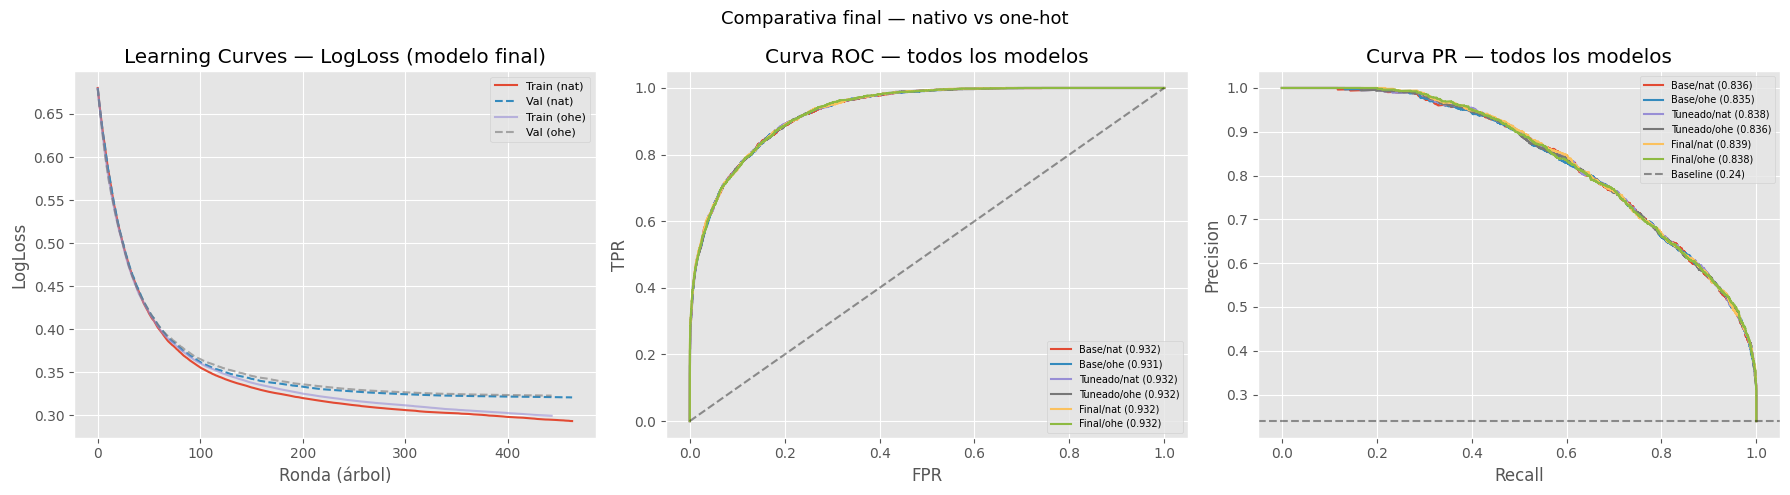

In [28]:
print("\n" + "─" * 65)
print("6. Generando gráfico comparativo final...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparativa final — nativo vs one-hot", fontsize=13)

ax = axes[0]
ax.plot(hist_final_nat['loss'],     label='Train (nat)')
ax.plot(hist_final_nat['val_loss'], label='Val (nat)',  linestyle='--')
ax.plot(hist_final_ohe['loss'],     label='Train (ohe)', alpha=0.6)
ax.plot(hist_final_ohe['val_loss'], label='Val (ohe)',   alpha=0.6, linestyle='--')
ax.set_title("Learning Curves — LogLoss (modelo final)")
ax.set_xlabel("Ronda (árbol)"); ax.set_ylabel("LogLoss"); ax.legend(fontsize=8)

ax = axes[1]
for res, lbl in [
    (res_base_nat,    "Base/nat"),    (res_base_ohe,    "Base/ohe"),
    (res_tuneado_nat, "Tuneado/nat"), (res_tuneado_ohe, "Tuneado/ohe"),
    (res_final_nat,   "Final/nat"),   (res_final_ohe,   "Final/ohe"),
]:
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax.plot(fpr, tpr, label=f"{lbl} ({res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title("Curva ROC — todos los modelos")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=7)

ax = axes[2]
for res, lbl in [
    (res_base_nat,    "Base/nat"),    (res_base_ohe,    "Base/ohe"),
    (res_tuneado_nat, "Tuneado/nat"), (res_tuneado_ohe, "Tuneado/ohe"),
    (res_final_nat,   "Final/nat"),   (res_final_ohe,   "Final/ohe"),
]:
    prec, rec, _ = precision_recall_curve(y_test, res['prob'])
    ax.plot(rec, prec, label=f"{lbl} ({res['pr_auc']:.3f})")
ax.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
           label=f'Baseline ({y_test.mean():.2f})')
ax.set_title("Curva PR — todos los modelos")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["graficos"], "03_xgboost_evaluacion.png"),
            dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen en consola

In [29]:
print("\n" + "═" * 65)
print("RESUMEN COMPARATIVO — TEST")
print("═" * 65)
print(f"{'Modelo':<22} {'Encoding':<14} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>7} {'Acc':>7}")
print("─" * 65)
for res, m_lbl, p_lbl in [
    (res_base_nat,    "Base",    "nativo"),  (res_base_ohe,    "Base",    "one-hot"),
    (res_tuneado_nat, "Tuneado", "nativo"),  (res_tuneado_ohe, "Tuneado", "one-hot"),
    (res_final_nat,   "Final",   "nativo"),  (res_final_ohe,   "Final",   "one-hot"),
]:
    print(f"  {m_lbl:<20} {p_lbl:<14} "
          f"{res['auc']:>8.4f} {res['pr_auc']:>8.4f} "
          f"{res['f1']:>7.4f} {res['acc']:>7.4f}")
print("═" * 65)

print("\n✅  04_modelo_xgboost.ipynb completado")
print(f"\n   Archivos generados:")
print(f"   · {DIRS['modelos']}/modelo_xgboost_final.json")
print(f"   · {DIRS['modelos']}/modelo_xgboost_best.json")
print(f"   · {DIRS['modelos']}/metricas_xgboost.json")
print(f"   · {DIRS['graficos']}/03_xgboost_evaluacion.png")
print(f"   · {DIRS['ablation']}/01_modelo_base/")
print(f"   · {DIRS['ablation']}/02_modelo_tuneado_optuna/")
print(f"   · {DIRS['ablation']}/03_modelo_final/")
print(f"   · {DIRS['ablation']}/optuna_trials.csv")
print(f"   · {DIRS['ablation']}/optuna_param_importances.png")
print("═" * 65)


═════════════════════════════════════════════════════════════════
RESUMEN COMPARATIVO — TEST
═════════════════════════════════════════════════════════════════
Modelo                 Encoding        ROC-AUC   PR-AUC      F1     Acc
─────────────────────────────────────────────────────────────────
  Base                 nativo           0.9315   0.8361  0.7116  0.8336
  Base                 one-hot          0.9314   0.8354  0.7151  0.8353
  Tuneado              nativo           0.9322   0.8377  0.7157  0.8368
  Tuneado              one-hot          0.9317   0.8364  0.7130  0.8343
  Final                nativo           0.9323   0.8388  0.7163  0.8378
  Final                one-hot          0.9321   0.8377  0.7128  0.8349
═════════════════════════════════════════════════════════════════

✅  04_modelo_xgboost.ipynb completado

   Archivos generados:
   · modelo_final/modelo_xgboost_final.json
   · modelo_final/modelo_xgboost_best.json
   · modelo_final/metricas_xgboost.json
   · plots/mod